# Training-data sensor fingerprints

Profile **every sensor column** in `te_process.csv`, using **training rows only** (`source == "train"`).

For each column we build a behavioral fingerprint: distribution, missingness, uniqueness, rate of change, autocorrelation, and FFT/frequency shape. From that fingerprint we infer a *role-like* description (smooth measured variable vs held/sampled vs noisy analog vs tightly regulated), with an explicit **confidence** and the evidence that supports it.

Rules of the write-up:

- Do **not** invent physical names ("reactor temperature", "A-feed", …).
- Prefer a cautious, evidence-backed sentence over a confident guess.
- Column prefixes (`xmeas_*` / `xmv_*`) are **not** used as classification features. They are compared only at the end, as a post-hoc sanity check.


In [1]:
from __future__ import annotations

from collections import defaultdict
from dataclasses import dataclass
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 80)

CSV_PATH = Path("te_process.csv")
META_COLS = ["faultNumber", "simulationRun", "sample", "source", "fault_status"]
RUNS_PER_FAULT = 8
CHUNKSIZE = 150_000
FULL_TRAIN_STATS = True
LOW_FREQ_CUTOFF = 0.05
SPARK_WIDTH = 56
ACF_LAGS = (1, 2, 5, 10, 20)

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

print("config")
print(f"  csv              {CSV_PATH.resolve()}")
print(f"  runs_per_fault   {RUNS_PER_FAULT}")
print(f"  full_train_stats {FULL_TRAIN_STATS}")



config
  csv              /Users/ob/Projects/hackathon_csv/te_process.csv
  runs_per_fault   8
  full_train_stats True


## Pretty-print helpers

Number formatting, sparklines, section rules, and HTML cards used by later cells.


In [2]:
SPARK_BLOCKS = "▁▂▃▄▅▆▇█"

CLASS_COLORS = {
    "periodically sampled / held measurement": "#0d7377",
    "tightly regulated near-constant variable": "#6b4c9a",
    "continuous measured process variable": "#1d4e89",
    "noisy continuous analog variable": "#5c6570",
    "percent-scale variable (possible actuator or level)": "#c05621",
    "ambiguous / mixed behavioral signature": "#9a3412",
}


def fmt_num(x, digits=4) -> str:
    if x is None or (isinstance(x, (float, np.floating)) and not np.isfinite(x)):
        return "n/a"
    if isinstance(x, (int, np.integer)):
        return f"{int(x):,}"
    ax = abs(float(x))
    if ax == 0:
        return "0"
    if ax >= 10000 or (0 < ax < 0.01):
        return f"{float(x):.4g}"
    if ax >= 100:
        return f"{float(x):.2f}"
    if ax >= 10:
        return f"{float(x):.3f}"
    return f"{float(x):.{digits}f}"


def fmt_pct(x) -> str:
    if x is None or not np.isfinite(x):
        return "n/a"
    return f"{100 * float(x):.2f}%"


def sparkline(values, width=SPARK_WIDTH) -> str:
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return " " * width
    idx = np.linspace(0, x.size - 1, width).astype(int)
    y = x[idx]
    lo, hi = float(np.min(y)), float(np.max(y))
    if hi - lo < 1e-15:
        return SPARK_BLOCKS[0] * width
    scaled = (y - lo) / (hi - lo)
    return "".join(SPARK_BLOCKS[min(7, int(v * 7))] for v in scaled)


def hr(title: str | None = None, width: int = 72) -> None:
    if not title:
        print("─" * width)
        return
    inner = f"  {title}  "
    pad = max(width - len(inner), 0)
    left = pad // 2
    print(f"{'─' * left}{inner}{'─' * (pad - left)}")


def print_kv(rows: list[tuple[str, str]], key_width: int = 18) -> None:
    for k, v in rows:
        print(f"  {k:<{key_width}} {v}")


def inject_css() -> None:
    display(HTML("""
<style>
.fp-card, .fp-table {
  color: var(--vscode-editor-foreground, var(--jp-content-font-color1, CanvasText));
}
.fp-card {
  border: 1px solid color-mix(in srgb, currentColor 22%, transparent);
  border-left: 6px solid var(--accent, currentColor);
  padding: 12px 16px;
  margin: 10px 0;
  background: color-mix(in srgb, currentColor 6%, transparent);
  max-width: 980px;
}
.fp-head {display:flex; justify-content:space-between; gap:12px; align-items:baseline;}
.fp-name {font-size:16px; font-weight:650; font-family:ui-monospace,SFMono-Regular,Menlo,monospace;
          color: inherit;}
.fp-conf {font-weight:650; font-variant-numeric:tabular-nums; white-space:nowrap;}
.fp-label {margin:4px 0 8px; font-size:13.5px; color: inherit; opacity: 0.85;}
.fp-narr {line-height:1.5; color: inherit;}
.fp-spark {font-family:ui-monospace,SFMono-Regular,Menlo,monospace; font-size:13px;
           letter-spacing:0; margin:8px 0 2px; color: inherit;}
.fp-grid {display:grid; grid-template-columns:158px 1fr; gap:3px 14px; margin-top:10px;
          font-family:ui-monospace,SFMono-Regular,Menlo,monospace; font-size:12px;
          color: inherit;}
.fp-k {color: inherit; opacity: 0.72;}
.fp-ev {margin:8px 0 0; padding-left:18px; color: inherit; font-size:13px;}
.fp-table {border-collapse:collapse; width:100%; font-size:12.5px;}
.fp-table th {text-align:left; border-bottom:1px solid color-mix(in srgb, currentColor 25%, transparent);
              padding:6px 8px; color: inherit; opacity: 0.8;}
.fp-table td {border-bottom:1px solid color-mix(in srgb, currentColor 12%, transparent);
              padding:5px 8px; font-variant-numeric:tabular-nums; color: inherit;
              font-family:ui-monospace,SFMono-Regular,Menlo,monospace; font-size:12px; vertical-align:top;}
.fp-pill {display:inline-block; padding:1px 8px; border:1px solid color-mix(in srgb, currentColor 30%, transparent);
          border-radius:999px; font-size:11px; color: inherit;}
.fp-caption {font-size:12px; margin-top:6px; color: inherit; opacity: 0.8;}
</style>
"""))


inject_css()
print("pretty-print helpers ready")



pretty-print helpers ready


## Load training data and compute global stats

Training occupies a contiguous prefix of the CSV (5,250,000 rows: 21 faults × 500 runs × 500 samples). One stream:

1. **Every training row** → count, missing %, mean, std, min, max (Welford).
2. **First `RUNS_PER_FAULT` complete runs of each fault** → dynamics, FFT, percentiles, uniqueness, correlations.

TE runs are i.i.d. simulations, so the first 8 runs of a fault are as representative as a random 8.


In [3]:
def sensor_columns(columns) -> list[str]:
    return [c for c in columns if c.startswith("xmeas_") or c.startswith("xmv_")]


def iter_training_chunks(path: Path, chunksize: int = CHUNKSIZE):
    """Yield training-only chunks; stop as soon as `source` leaves train."""
    for chunk in pd.read_csv(path, chunksize=chunksize):
        mask = chunk["source"] == "train"
        if not mask.any():
            break
        yield chunk.loc[mask]
        if not bool(mask.all()):
            break


@dataclass
class GlobalStats:
    names: list[str]
    n: np.ndarray
    mean: np.ndarray
    m2: np.ndarray
    min: np.ndarray
    max: np.ndarray
    n_missing: np.ndarray
    n_rows: int = 0

    @classmethod
    def for_names(cls, names: list[str]) -> "GlobalStats":
        k = len(names)
        return cls(
            names=names,
            n=np.zeros(k, dtype=np.int64),
            mean=np.zeros(k, dtype=np.float64),
            m2=np.zeros(k, dtype=np.float64),
            min=np.full(k, np.inf),
            max=np.full(k, -np.inf),
            n_missing=np.zeros(k, dtype=np.int64),
        )

    def update(self, frame: pd.DataFrame) -> None:
        arr = frame[self.names].to_numpy(dtype=np.float64, copy=False)
        self.n_rows += int(arr.shape[0])
        valid = np.isfinite(arr)
        self.n_missing += (~valid).sum(axis=0)
        for j in range(arr.shape[1]):
            x = arr[valid[:, j], j]
            if x.size == 0:
                continue
            n_b = int(x.size)
            mean_b = float(x.mean())
            m2_b = float(((x - mean_b) ** 2).sum())
            n_a = int(self.n[j])
            if n_a == 0:
                self.n[j] = n_b
                self.mean[j] = mean_b
                self.m2[j] = m2_b
            else:
                delta = mean_b - self.mean[j]
                n = n_a + n_b
                self.mean[j] += delta * n_b / n
                self.m2[j] += m2_b + delta * delta * n_a * n_b / n
                self.n[j] = n
            xmin, xmax = float(x.min()), float(x.max())
            if xmin < self.min[j]:
                self.min[j] = xmin
            if xmax > self.max[j]:
                self.max[j] = xmax

    def as_frame(self) -> pd.DataFrame:
        std = np.sqrt(np.where(self.n > 1, self.m2 / np.maximum(self.n - 1, 1), np.nan))
        missing = np.where(self.n_rows > 0, self.n_missing / self.n_rows, np.nan)
        return pd.DataFrame(
            {
                "sensor": self.names,
                "n": self.n,
                "missing_pct": missing,
                "mean": self.mean,
                "std": std,
                "min": self.min,
                "max": self.max,
            }
        ).set_index("sensor")


class RunAssembler:
    """Reassemble complete (fault, run) groups that may split across chunks."""

    def __init__(self):
        self.key = None
        self.parts: list[pd.DataFrame] = []

    def feed(self, chunk: pd.DataFrame, keep_fault) -> list[tuple[tuple, pd.DataFrame]]:
        completed = []
        for key, group in chunk.groupby(["faultNumber", "simulationRun"], sort=False):
            want = bool(keep_fault(key[0]))
            if self.key is None:
                self.key = key
                self.parts = [group] if want else []
            elif key == self.key:
                if self.parts:
                    self.parts.append(group)
            else:
                if self.parts:
                    completed.append((self.key, pd.concat(self.parts, ignore_index=True)))
                self.key = key
                self.parts = [group] if want else []
        return completed

    def flush(self) -> list[tuple[tuple, pd.DataFrame]]:
        if self.key is None or not self.parts:
            self.key = None
            self.parts = []
            return []
        out = [(self.key, pd.concat(self.parts, ignore_index=True))]
        self.key = None
        self.parts = []
        return out


def load_training_profile(path: Path = CSV_PATH):
    t0 = perf_counter()
    names = None
    glob = None
    assembler = RunAssembler()
    sampled_runs: list[pd.DataFrame] = []
    kept: dict[float, int] = defaultdict(int)
    n_chunks = 0
    still_sampling = True

    for chunk in iter_training_chunks(path):
        n_chunks += 1
        if names is None:
            names = sensor_columns(chunk.columns)
            glob = GlobalStats.for_names(names)
        glob.update(chunk)

        if still_sampling:
            for key, run_df in assembler.feed(chunk, lambda f: kept[f] < RUNS_PER_FAULT):
                fault = key[0]
                if kept[fault] < RUNS_PER_FAULT:
                    sampled_runs.append(run_df)
                    kept[fault] += 1
            if len(kept) >= 21 and min(kept.values()) >= RUNS_PER_FAULT:
                still_sampling = False
                assembler = RunAssembler()

        if n_chunks == 1 or n_chunks % 8 == 0:
            print(f"  chunk {n_chunks:2d}  rows={glob.n_rows:,}  sampled_runs={len(sampled_runs)}")

        if (not FULL_TRAIN_STATS) and (not still_sampling):
            break

    if still_sampling:
        for key, run_df in assembler.flush():
            fault = key[0]
            if kept[fault] < RUNS_PER_FAULT:
                sampled_runs.append(run_df)
                kept[fault] += 1

    sample = pd.concat(sampled_runs, ignore_index=True)
    elapsed = perf_counter() - t0

    hr("training load")
    print_kv(
        [
            ("chunks", str(n_chunks)),
            ("train rows", f"{glob.n_rows:,}"),
            ("sampled runs", f"{len(sampled_runs)}  ({RUNS_PER_FAULT} per fault × {len(kept)} faults)"),
            ("sampled rows", f"{len(sample):,}"),
            ("sensors", str(len(names))),
            ("elapsed", f"{elapsed:.1f}s"),
        ]
    )
    print()
    print("runs kept per fault:")
    for fault in sorted(kept):
        print(f"  fault {int(fault):2d}: {kept[fault]} runs")
    return glob, sample, sampled_runs


glob_stats, sample_df, sampled_runs = load_training_profile()
display(sample_df[META_COLS + sensor_columns(sample_df.columns)[:4]].head(3))



  chunk  1  rows=150,000  sampled_runs=8
  chunk  8  rows=1,200,000  sampled_runs=168
  chunk 16  rows=2,400,000  sampled_runs=168
  chunk 24  rows=3,600,000  sampled_runs=168
  chunk 32  rows=4,800,000  sampled_runs=168
───────────────────────────  training load  ────────────────────────────
  chunks             35
  train rows         5,250,000
  sampled runs       168  (8 per fault × 21 faults)
  sampled rows       84,000
  sensors            52
  elapsed            7.7s

runs kept per fault:
  fault  0: 8 runs
  fault  1: 8 runs
  fault  2: 8 runs
  fault  3: 8 runs
  fault  4: 8 runs
  fault  5: 8 runs
  fault  6: 8 runs
  fault  7: 8 runs
  fault  8: 8 runs
  fault  9: 8 runs
  fault 10: 8 runs
  fault 11: 8 runs
  fault 12: 8 runs
  fault 13: 8 runs
  fault 14: 8 runs
  fault 15: 8 runs
  fault 16: 8 runs
  fault 17: 8 runs
  fault 18: 8 runs
  fault 19: 8 runs
  fault 20: 8 runs


,faultNumber,simulationRun,sample,source,fault_status,xmeas_1,xmeas_2,xmeas_3,xmeas_4
0,0.0,1.0,1,train,normal,0.25038,3674.0,4529.0,9.2320
1,0.0,1.0,2,train,normal,0.25109,3659.4,4556.6,9.4264
2,0.0,1.0,3,train,normal,0.25038,3660.3,4477.8,9.4426


## Per-sensor fingerprint functions

Distributional stats from the full training stream plus rate-of-change, hold/update period, autocorrelation, and FFT features averaged across sampled runs.


In [4]:
def _finite(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    return x[np.isfinite(x)]


def acf_at_lags(x: np.ndarray, lags=ACF_LAGS) -> dict[int, float]:
    x = _finite(x)
    out = {int(lag): float("nan") for lag in lags}
    if x.size < (max(lags) + 3):
        return out
    y = x - x.mean()
    denom = float(np.dot(y, y))
    if denom <= 0:
        return out
    for lag in lags:
        lag = int(lag)
        out[lag] = float(np.dot(y[:-lag], y[lag:]) / denom)
    return out


def fft_features(runs: list[np.ndarray]) -> dict[str, float]:
    acc = None
    n_used = 0
    freqs = None
    for raw in runs:
        x = _finite(raw)
        if x.size < 32:
            continue
        x = x - x.mean()
        if np.allclose(x, 0):
            continue
        w = np.hanning(x.size)
        ps = np.abs(np.fft.rfft(x * w)) ** 2
        ps_sum = float(ps.sum())
        if ps_sum <= 0:
            continue
        p = ps / ps_sum
        if acc is not None and p.shape != acc.shape:
            continue
        acc = p if acc is None else acc + p
        freqs = np.fft.rfftfreq(x.size, d=1.0)
        n_used += 1
    empty = {
        "low_band_frac": np.nan,
        "high_band_frac": np.nan,
        "spectral_entropy": np.nan,
        "spectral_centroid": np.nan,
        "dominant_freq": np.nan,
        "n_spectra": 0,
    }
    if acc is None or freqs is None:
        return empty
    p = acc / n_used
    p = np.clip(p, 1e-30, None)
    p = p / p.sum()
    entropy = float(-(p * np.log(p)).sum() / np.log(p.size))
    centroid = float(np.sum(freqs * p))
    dominant = float(freqs[int(np.argmax(p))])
    return {
        "low_band_frac": float(p[freqs <= LOW_FREQ_CUTOFF].sum()),
        "high_band_frac": float(p[freqs >= 0.20].sum()),
        "spectral_entropy": entropy,
        "spectral_centroid": centroid,
        "dominant_freq": dominant,
        "n_spectra": n_used,
    }


def rate_of_change_features(runs: list[np.ndarray], value_range: float) -> dict[str, float]:
    diffs = []
    for raw in runs:
        x = _finite(raw)
        if x.size < 3:
            continue
        diffs.append(np.diff(x))
    if not diffs:
        return {
            "mean_abs_delta": np.nan,
            "median_abs_delta": np.nan,
            "p95_abs_delta": np.nan,
            "max_abs_delta": np.nan,
            "rel_mean_abs_delta": np.nan,
            "jump_rate": np.nan,
            "sign_change_rate": np.nan,
        }
    d = np.concatenate(diffs)
    abs_d = np.abs(d)
    med = float(np.median(abs_d))
    jump = abs_d > (4.0 * med + 1e-12)
    signs = np.sign(d)
    sign_changes = signs[1:] * signs[:-1] < 0
    rng = value_range if value_range > 0 else np.nan
    return {
        "mean_abs_delta": float(np.mean(abs_d)),
        "median_abs_delta": med,
        "p95_abs_delta": float(np.percentile(abs_d, 95)),
        "max_abs_delta": float(np.max(abs_d)),
        "rel_mean_abs_delta": float(np.mean(abs_d) / rng) if np.isfinite(rng) else np.nan,
        "jump_rate": float(np.mean(jump)),
        "sign_change_rate": float(np.mean(sign_changes)) if sign_changes.size else np.nan,
    }


def hold_features(runs: list[np.ndarray]) -> dict[str, float]:
    hold_fracs = []
    periods = []
    regularities = []
    for raw in runs:
        x = _finite(raw)
        if x.size < 8:
            continue
        scale = max(abs(float(np.mean(x))), float(np.ptp(x)), 1.0)
        eps = 1e-9 * scale + 1e-12
        d = np.diff(x)
        held = np.abs(d) <= eps
        hold_fracs.append(float(np.mean(held)))
        change_idx = np.flatnonzero(~held)
        if change_idx.size >= 3:
            gaps = np.diff(change_idx)
            period = float(np.median(gaps))
            periods.append(period)
            mu = float(np.mean(gaps))
            if mu > 0:
                regularities.append(float(max(0.0, 1.0 - np.std(gaps) / mu)))
    return {
        "hold_frac": float(np.mean(hold_fracs)) if hold_fracs else np.nan,
        "update_period": float(np.median(periods)) if periods else np.nan,
        "period_regularity": float(np.mean(regularities)) if regularities else np.nan,
    }


def percentiles_and_unique(series: pd.Series) -> dict[str, float]:
    x = pd.to_numeric(series, errors="coerce").dropna().to_numpy(dtype=float)
    qs = (1, 5, 25, 50, 75, 95, 99)
    pct = {} if x.size == 0 else {f"p{q:02d}": float(np.percentile(x, q)) for q in qs}
    if x.size == 0:
        pct = {f"p{q:02d}": np.nan for q in qs}
    nunique = int(pd.Series(x).nunique()) if x.size else 0
    cv = float(np.std(x, ddof=1) / (abs(np.mean(x)) + 1e-12)) if x.size > 1 else np.nan
    return {**pct, "n_unique_sample": nunique, "cv_sample": cv}


def scale_hint(lo: float, hi: float) -> str:
    if not np.isfinite(lo) or not np.isfinite(hi):
        return "unknown"
    if hi <= 1.5 and lo >= -0.15:
        return "fraction / ratio-like"
    if lo > -5 and hi < 105 and (hi - lo) >= 5:
        return "percent-like (roughly 0–100)"
    if hi >= 200:
        return "large engineering-scale"
    return "small engineering-scale"


def series_by_run(sample: pd.DataFrame, col: str) -> list[np.ndarray]:
    runs = []
    for _, g in sample.groupby(["faultNumber", "simulationRun"], sort=False):
        g = g.sort_values("sample")
        runs.append(g[col].to_numpy(dtype=float))
    return runs


print("fingerprint metric functions ready")



fingerprint metric functions ready


In [5]:
def correlation_partners(
    sample: pd.DataFrame,
    sensors: list[str],
    level_thresh: float = 0.45,
    diff_thresh: float = 0.55,
    top_k: int = 3,
):
    levels = sample[sensors].apply(pd.to_numeric, errors="coerce")
    corr_level = levels.corr()

    diff_parts = []
    for _, g in sample.groupby(["faultNumber", "simulationRun"], sort=False):
        d = g[sensors].apply(pd.to_numeric, errors="coerce").diff().iloc[1:]
        diff_parts.append(d)
    corr_diff = pd.concat(diff_parts, ignore_index=True).corr()

    partners: dict[str, list[tuple[str, float, str]]] = {}
    for col in sensors:
        scored: list[tuple[str, float, str]] = []
        for other in sensors:
            if other == col:
                continue
            r_l = corr_level.loc[col, other]
            r_d = corr_diff.loc[col, other]
            if np.isfinite(r_l) and abs(r_l) >= level_thresh:
                scored.append((other, float(r_l), "level"))
            if np.isfinite(r_d) and abs(r_d) >= diff_thresh:
                scored.append((other, float(r_d), "diff"))
        scored.sort(key=lambda t: -abs(t[1]))
        # unique others, strongest first
        seen = set()
        picked = []
        for item in scored:
            if item[0] in seen:
                continue
            seen.add(item[0])
            picked.append(item)
            if len(picked) >= top_k:
                break
        partners[col] = picked
    return corr_level, corr_diff, partners


def tracking_pairs(corr_diff: pd.DataFrame, thresh: float = 0.85) -> list[tuple[str, str, float]]:
    cols = list(corr_diff.columns)
    pairs = []
    for i, a in enumerate(cols):
        for b in cols[i + 1 :]:
            r = corr_diff.loc[a, b]
            if np.isfinite(r) and abs(r) >= thresh:
                pairs.append((a, b, float(r)))
    pairs.sort(key=lambda t: -abs(t[2]))
    return pairs


def build_fingerprints(
    glob: GlobalStats,
    sample: pd.DataFrame,
    sensors: list[str] | None = None,
) -> pd.DataFrame:
    sensors = sensors or glob.names
    glob_df = glob.as_frame()
    rows = []
    hr("computing per-sensor dynamics")
    for i, col in enumerate(sensors, start=1):
        runs = series_by_run(sample, col)
        g = glob_df.loc[col]
        rng = float(g["max"] - g["min"]) if np.isfinite(g["max"]) else np.nan
        acf_runs = [acf_at_lags(x) for x in runs]
        acf_mean = {lag: float(np.nanmean([d[lag] for d in acf_runs])) for lag in ACF_LAGS}
        roc = rate_of_change_features(runs, rng)
        held = hold_features(runs)
        spec = fft_features(runs)
        dist = percentiles_and_unique(sample[col])
        trace_src = next((x for x in runs if np.isfinite(x).sum() >= 16), runs[0])
        rows.append(
            {
                "sensor": col,
                "n_train": int(g["n"]),
                "missing_pct": float(g["missing_pct"]),
                "mean": float(g["mean"]),
                "std": float(g["std"]),
                "min": float(g["min"]),
                "max": float(g["max"]),
                "range": rng,
                "cv": float(dist["cv_sample"]),
                **dist,
                **{f"acf_{lag}": acf_mean[lag] for lag in ACF_LAGS},
                **roc,
                **held,
                **spec,
                "scale_hint": scale_hint(float(g["min"]), float(g["max"])),
                "spark": sparkline(trace_src),
            }
        )
        if i % 10 == 0 or i == len(sensors):
            print(f"  {i}/{len(sensors)} sensors")
    return pd.DataFrame(rows).set_index("sensor")


sensors = glob_stats.names
fp = build_fingerprints(glob_stats, sample_df, sensors)
corr_level, corr_diff, partners = correlation_partners(sample_df, sensors)
pairs = tracking_pairs(corr_diff, thresh=0.85)

hr("distribution snapshot (training)")
show_cols = ["mean", "std", "min", "max", "missing_pct", "n_unique_sample", "acf_1", "hold_frac"]
display(fp[show_cols].round(4))



───────────────────  computing per-sensor dynamics  ────────────────────
  10/52 sensors
  20/52 sensors
  30/52 sensors
  40/52 sensors
  50/52 sensors
  52/52 sensors
──────────────────  distribution snapshot (training)  ──────────────────


,mean,std,min,max,missing_pct,n_unique_sample,acf_1,hold_frac
sensor,,,,,,,,
xmeas_1,0.2608,0.1461,-0.0047,1.0175,0.0,28318,0.7936,0.0449
xmeas_2,3663.7773,42.7776,3327.4000,3906.7000,0.0,2671,0.4794,0.0446
xmeas_3,4506.1779,108.6998,3540.7000,5175.8000,0.0,6477,0.6460,0.0444
xmeas_4,9.3692,0.3564,6.6399,12.2400,0.0,13260,0.5744,0.0442
xmeas_5,26.9016,0.2311,25.3860,28.4860,0.0,1833,0.0157,0.0450
xmeas_6,42.3629,0.3133,39.6560,44.6530,0.0,2224,0.1999,0.0446
xmeas_7,2722.1495,74.2792,2413.8000,3000.5000,0.0,3639,0.9705,0.0588
xmeas_8,74.8880,1.3155,61.8730,87.0170,0.0,7694,0.4496,0.0443
xmeas_9,120.4002,0.0713,119.6300,121.0100,0.0,120,0.0601,0.1649


## Classify each sensor from evidence, not from the name

Scores are additive clues. The winning label is the highest score; if the runner-up is close, confidence is cut and the alternative is named. Prefixes `xmeas_` / `xmv_` are ignored here on purpose.


In [6]:
def _clip_conf(raw: float, mixed: bool) -> float:
    conf = float(np.clip(0.38 + 0.42 * raw, 0.40, 0.88))
    if mixed:
        conf = min(conf, 0.58)
    return round(conf, 2)


def classify_row(name: str, row: pd.Series, allies: list[tuple[str, float, str]]) -> dict:
    scores = {
        "periodically sampled / held measurement": 0.0,
        "tightly regulated near-constant variable": 0.0,
        "continuous measured process variable": 0.0,
        "noisy continuous analog variable": 0.0,
        "percent-scale variable (possible actuator or level)": 0.0,
    }
    evidence: list[str] = []

    hold = float(row["hold_frac"]) if np.isfinite(row["hold_frac"]) else 0.0
    period = float(row["update_period"]) if np.isfinite(row["update_period"]) else np.nan
    regularity = float(row["period_regularity"]) if np.isfinite(row["period_regularity"]) else 0.0
    ac1 = float(row["acf_1"]) if np.isfinite(row["acf_1"]) else 0.0
    ac5 = float(row["acf_5"]) if np.isfinite(row["acf_5"]) else 0.0
    low = float(row["low_band_frac"]) if np.isfinite(row["low_band_frac"]) else 0.0
    ent = float(row["spectral_entropy"]) if np.isfinite(row["spectral_entropy"]) else 1.0
    cv = float(row["cv"]) if np.isfinite(row["cv"]) else np.nan
    rel_d = float(row["rel_mean_abs_delta"]) if np.isfinite(row["rel_mean_abs_delta"]) else np.nan
    rng = float(row["range"])
    mean = float(row["mean"])
    lo, hi = float(row["min"]), float(row["max"])

    # --- held / periodically sampled ---
    if hold >= 0.35 and np.isfinite(period) and period >= 1.8:
        scores["periodically sampled / held measurement"] += 0.70
        evidence.append(
            f"the value is piecewise-constant {fmt_pct(hold)} of the time, with updates about every {fmt_num(period)} samples"
        )
        if regularity >= 0.75:
            scores["periodically sampled / held measurement"] += 0.18
            evidence.append(f"the update spacing is regular (regularity {fmt_num(regularity)})")

    # --- tightly regulated ---
    rel_range = rng / (abs(mean) + 1e-12) if np.isfinite(rng) and np.isfinite(mean) else np.nan
    if np.isfinite(cv) and cv < 0.003 and np.isfinite(rel_range) and rel_range < 0.02:
        scores["tightly regulated near-constant variable"] += 0.72
        evidence.append(
            f"the series barely moves (CV {fmt_num(cv)}, range {fmt_num(lo)}–{fmt_num(hi)} around mean {fmt_num(mean)})"
        )
        if row["n_unique_sample"] <= 80:
            scores["tightly regulated near-constant variable"] += 0.08
            evidence.append(f"only {int(row['n_unique_sample'])} distinct values in the profile sample")

    # --- smooth continuous ---
    if ac1 >= 0.85 and low >= 0.70:
        scores["continuous measured process variable"] += 0.62
        evidence.append(
            f"it changes gradually (lag-1 autocorrelation {fmt_num(ac1)}, lag-5 {fmt_num(ac5)})"
        )
        evidence.append(
            f"{fmt_pct(low)} of spectral power sits below {LOW_FREQ_CUTOFF} cycles/sample (smooth, low-frequency)"
        )
        if np.isfinite(rel_d) and rel_d < 0.04:
            scores["continuous measured process variable"] += 0.10
    elif ac1 >= 0.55 and low >= 0.45 and hold < 0.25:
        scores["continuous measured process variable"] += 0.28
        evidence.append(
            f"moderate smoothness (lag-1 autocorrelation {fmt_num(ac1)}, low-band power {fmt_pct(low)})"
        )

    if allies:
        ally_txt = ", ".join(f"{a} ({kind} r={fmt_num(r)})" for a, r, kind in allies[:2])
        scores["continuous measured process variable"] += 0.12 if ac1 >= 0.5 else 0.04
        evidence.append(f"it co-moves with {ally_txt}")

    # --- noisy analog ---
    if hold < 0.15 and ac1 < 0.25 and ent >= 0.85:
        scores["noisy continuous analog variable"] += 0.58
        evidence.append(
            f"sample-to-sample changes look noisy (lag-1 ACF {fmt_num(ac1)}, spectral entropy {fmt_num(ent)})"
        )
        if np.isfinite(rel_d) and rel_d > 0.10:
            scores["noisy continuous analog variable"] += 0.12
            evidence.append(f"mean |Δ| is {fmt_pct(rel_d)} of the observed range")

    # --- percent-scale / possible actuator (weak; never the only loud signal) ---
    percentish = (lo > -5) and (hi < 105) and (hi - lo >= 15) and (lo < 45) and (hi > 55)
    if percentish and hold < 0.25:
        scores["percent-scale variable (possible actuator or level)"] += 0.22
        evidence.append(
            f"the observed range {fmt_num(lo)}–{fmt_num(hi)} is consistent with a percent-scale (0–100) quantity"
        )
        sat = float(np.mean((sample_df[name] <= 1.0) | (sample_df[name] >= 99.0))) if percentish else 0.0
        if sat >= 0.01:
            scores["percent-scale variable (possible actuator or level)"] += 0.12
            evidence.append(f"about {fmt_pct(sat)} of sampled values sit at the 0/100 edges (saturation-like)")

    ranked = sorted(scores.items(), key=lambda kv: -kv[1])
    primary, pscore = ranked[0]
    secondary, sscore = ranked[1]
    mixed = (pscore - sscore) < 0.12 or pscore < 0.35
    if pscore < 0.28:
        label = "ambiguous / mixed behavioral signature"
        primary = label
        mixed = True
        evidence.append(
            f"lag-1 ACF is only {fmt_num(ac1)} and low-band power is {fmt_pct(low)}, so the series is analog but neither clearly smooth nor held"
        )
    elif mixed and sscore >= 0.20:
        label = f"{primary} (also consistent with {secondary})"
        evidence.append(f"a competing reading is “{secondary}” (score gap only {fmt_num(pscore - sscore)})")
    else:
        label = primary

    conf = _clip_conf(pscore, mixed=mixed)
    if primary.startswith("percent-scale") and pscore < 0.45:
        conf = min(conf, 0.52)

    return {
        "label": label,
        "confidence": conf,
        "primary": primary,
        "secondary": secondary,
        "score_primary": round(pscore, 3),
        "score_secondary": round(sscore, 3),
        "evidence": evidence,
        "allies": allies,
    }


def _article(label: str) -> str:
    head = label.strip().split()[0].lower()
    return "an" if head[:1] in "aeiou" else "a"


def narrate(name: str, info: dict) -> str:
    ev = info["evidence"]
    because = ""
    if ev:
        bits = ev[:3]
        if len(bits) == 1:
            because = f" because {bits[0]}"
        elif len(bits) == 2:
            because = f" because {bits[0]}, and {bits[1]}"
        else:
            because = f" because {bits[0]}, {bits[1]}, and {bits[2]}"
    return (
        f"{name} appears to be {_article(info['label'])} {info['label']}; "
        f"confidence {info['confidence']:.2f},{because}."
    )


def attach_classifications(fp: pd.DataFrame) -> pd.DataFrame:
    labels, confs, narratives, evids, primaries = [], [], [], [], []
    for name, row in fp.iterrows():
        info = classify_row(name, row, partners.get(name, []))
        labels.append(info["label"])
        confs.append(info["confidence"])
        narratives.append(narrate(name, info))
        evids.append(info["evidence"])
        primaries.append(info["primary"])
    out = fp.copy()
    out["label"] = labels
    out["confidence"] = confs
    out["narrative"] = narratives
    out["evidence"] = evids
    out["primary"] = primaries
    return out


classified = attach_classifications(fp)
hr("class counts")
print(classified["primary"].value_counts().to_string())
print()
print("confidence: "
      f"min={classified['confidence'].min():.2f}  "
      f"median={classified['confidence'].median():.2f}  "
      f"max={classified['confidence'].max():.2f}")



────────────────────────────  class counts  ────────────────────────────
primary
periodically sampled / held measurement                19
continuous measured process variable                   17
noisy continuous analog variable                        9
ambiguous / mixed behavioral signature                  4
percent-scale variable (possible actuator or level)     2
tightly regulated near-constant variable                1

confidence: min=0.40  median=0.71  max=0.75


## Summary table and per-sensor cards

Compact table first, then one evidence card per sensor. Confidence is intentionally capped below 0.90.


In [7]:
def render_summary(df: pd.DataFrame) -> None:
    order = (
        df.reset_index()
        .sort_values(["primary", "confidence", "sensor"], ascending=[True, False, True])
    )
    rows = []
    for _, r in order.iterrows():
        name = r["sensor"]
        ally = partners.get(name, [])
        ally_s = ", ".join(f"{a} ({fmt_num(v)})" for a, v, _ in ally[:2]) or "—"
        color = CLASS_COLORS.get(r["primary"], "#57606a")
        rows.append(
            "<tr>"
            f"<td><b>{name}</b></td>"
            f"<td><span class='fp-pill' style='border-color:{color};color:{color}'>{r['label']}</span></td>"
            f"<td>{r['confidence']:.2f}</td>"
            f"<td>{fmt_num(r['mean'])} ± {fmt_num(r['std'])}</td>"
            f"<td>{fmt_num(r['min'])} → {fmt_num(r['max'])}</td>"
            f"<td>{fmt_pct(r['missing_pct'])}</td>"
            f"<td>{int(r['n_unique_sample']):,}</td>"
            f"<td>{fmt_num(r['acf_1'])}</td>"
            f"<td>{fmt_pct(r['hold_frac'])}</td>"
            f"<td>{fmt_num(r['update_period'])}</td>"
            f"<td>{fmt_pct(r['low_band_frac'])}</td>"
            f"<td>{ally_s}</td>"
            "</tr>"
        )
    html = f"""
    <table class="fp-table">
      <thead>
        <tr>
          <th>sensor</th><th>inferred role</th><th>conf</th><th>mean ± std</th>
          <th>min → max</th><th>missing</th><th>unique*</th><th>ACF₁</th>
          <th>hold</th><th>update</th><th>low-f</th><th>allies</th>
        </tr>
      </thead>
      <tbody>{''.join(rows)}</tbody>
    </table>
    <p class="fp-caption">
      *unique counts are from the stratified run sample, not the full 5.25M training rows.
      mean/std/min/max/missing use every training row.
    </p>
    """
    display(HTML(html))


def render_card(name: str, r: pd.Series) -> None:
    color = CLASS_COLORS.get(r["primary"], "#57606a")
    ally = partners.get(name, [])
    ally_s = ", ".join(f"{a} ({kind} r={fmt_num(v)})" for a, v, kind in ally) or "none above threshold"
    evid_li = "".join(f"<li>{e}</li>" for e in r["evidence"])
    grid = [
        ("range", f"{fmt_num(r['min'])} → {fmt_num(r['max'])}   ({r['scale_hint']})"),
        ("mean ± std", f"{fmt_num(r['mean'])} ± {fmt_num(r['std'])}    CV={fmt_num(r['cv'])}"),
        ("percentiles", f"p01={fmt_num(r['p01'])}  p25={fmt_num(r['p25'])}  p50={fmt_num(r['p50'])}  p75={fmt_num(r['p75'])}  p99={fmt_num(r['p99'])}"),
        ("missing / unique", f"{fmt_pct(r['missing_pct'])} missing,  {int(r['n_unique_sample']):,} unique in sample"),
        ("smoothness", f"ACF₁={fmt_num(r['acf_1'])}  ACF₅={fmt_num(r['acf_5'])}  ACF₁₀={fmt_num(r['acf_10'])}"),
        ("rate of change", f"mean|Δ|={fmt_num(r['mean_abs_delta'])}  ({fmt_pct(r['rel_mean_abs_delta'])} of range)  jump-rate={fmt_pct(r['jump_rate'])}"),
        ("spectrum", f"low-band={fmt_pct(r['low_band_frac'])}  high-band={fmt_pct(r['high_band_frac'])}  entropy={fmt_num(r['spectral_entropy'])}  peak f={fmt_num(r['dominant_freq'])}"),
        ("hold / sample", f"hold={fmt_pct(r['hold_frac'])}  update period={fmt_num(r['update_period'])} samples  regularity={fmt_num(r['period_regularity'])}"),
        ("allies", ally_s),
    ]
    grid_html = "".join(f"<div class='fp-k'>{k}</div><div>{v}</div>" for k, v in grid)
    html = f"""
    <div class="fp-card" style="--accent:{color}">
      <div class="fp-head">
        <div class="fp-name">{name}</div>
        <div class="fp-conf" style="color:{color}">confidence {r['confidence']:.2f}</div>
      </div>
      <div class="fp-label">{r['label']}</div>
      <div class="fp-narr">{r['narrative']}</div>
      <div class="fp-spark">{r['spark']}</div>
      <div class="fp-grid">{grid_html}</div>
      <ul class="fp-ev">{evid_li}</ul>
    </div>
    """
    display(HTML(html))


def print_card_text(name: str, r: pd.Series) -> None:
    hr(f"{name}   conf {r['confidence']:.2f}")
    print(f"  {r['label']}")
    print()
    print(f"  {r['narrative']}")
    print()
    print(f"  trace  {r['spark']}")
    print_kv(
        [
            ("range", f"{fmt_num(r['min'])} → {fmt_num(r['max'])}  ({r['scale_hint']})"),
            ("mean ± std", f"{fmt_num(r['mean'])} ± {fmt_num(r['std'])}"),
            ("percentiles", f"p01={fmt_num(r['p01'])}  p50={fmt_num(r['p50'])}  p99={fmt_num(r['p99'])}"),
            ("missing", fmt_pct(r["missing_pct"])),
            ("unique (sample)", f"{int(r['n_unique_sample']):,}"),
            ("ACF 1/5/10", f"{fmt_num(r['acf_1'])} / {fmt_num(r['acf_5'])} / {fmt_num(r['acf_10'])}"),
            ("mean |Δ|", f"{fmt_num(r['mean_abs_delta'])}  ({fmt_pct(r['rel_mean_abs_delta'])} of range)"),
            ("spectrum", f"low {fmt_pct(r['low_band_frac'])}  entropy {fmt_num(r['spectral_entropy'])}"),
            ("hold", f"{fmt_pct(r['hold_frac'])}  period {fmt_num(r['update_period'])}"),
        ]
    )
    print()


render_summary(classified)
print()
for name, row in classified.sort_values(["primary", "confidence"], ascending=[True, False]).iterrows():
    render_card(name, row)
    print_card_text(name, row)



sensor,inferred role,conf,mean ± std,min → max,missing,unique*,ACF₁,hold,update,low-f,allies
xmv_1,ambiguous / mixed behavioral signature,0.47,63.492 ± 3.2695,43.347 → 100.00,0.00%,"5,180",0.4919,2.25%,1.0000,31.33%,"xmv_2 (0.7709), xmeas_33 (-0.5693)"
xmeas_22,ambiguous / mixed behavioral signature,0.43,77.042 ± 1.3871,62.870 → 83.434,0.00%,"6,844",0.5627,4.47%,1.0000,43.34%,"xmv_6 (0.5544), xmeas_11 (0.5479)"
xmeas_2,ambiguous / mixed behavioral signature,0.40,3663.78 ± 42.778,3327.40 → 3906.70,0.00%,"2,671",0.4794,4.46%,1.0000,30.53%,—
xmeas_8,ambiguous / mixed behavioral signature,0.40,74.888 ± 1.3155,61.873 → 87.017,0.00%,"7,694",0.4496,4.43%,1.0000,49.13%,"xmeas_4 (-0.6689), xmeas_6 (-0.4899)"
xmeas_11,continuous measured process variable,0.73,79.760 ± 1.7598,68.219 → 87.591,0.00%,"7,229",0.8611,4.60%,1.0000,73.22%,"xmeas_35 (0.9372), xmeas_7 (-0.9265)"
xmeas_13,continuous measured process variable,0.73,2650.09 ± 74.853,2317.10 → 2945.40,0.00%,"3,718",0.9674,5.76%,1.0000,94.35%,"xmeas_7 (0.9973), xmeas_16 (0.9766)"
xmeas_16,continuous measured process variable,0.73,3120.43 ± 77.020,2870.90 → 3451.70,0.00%,"3,462",0.9672,6.09%,1.0000,93.59%,"xmeas_7 (0.9856), xmeas_13 (0.9766)"
xmeas_18,continuous measured process variable,0.73,66.002 ± 1.8171,52.119 → 74.669,0.00%,"10,919",0.9921,4.88%,1.0000,98.42%,"xmeas_19 (0.7826), xmv_9 (0.7610)"
xmeas_19,continuous measured process variable,0.73,245.63 ± 67.939,-3.3752 → 466.71,0.00%,"19,543",0.9889,4.57%,1.0000,98.90%,"xmv_9 (0.8669), xmeas_18 (0.7826)"
xmeas_20,continuous measured process variable,0.73,340.39 ± 11.008,232.45 → 400.71,0.00%,"5,908",0.9734,5.16%,1.0000,96.59%,"xmeas_29 (0.8808), xmeas_23 (0.8711)"


─────────────────────────  xmv_1   conf 0.47  ──────────────────────────
  ambiguous / mixed behavioral signature

  xmv_1 appears to be an ambiguous / mixed behavioral signature; confidence 0.47, because it co-moves with xmv_2 (level r=0.7709), xmeas_33 (level r=-0.5693), the observed range 43.347–100.00 is consistent with a percent-scale (0–100) quantity, and lag-1 ACF is only 0.4919 and low-band power is 31.33%, so the series is analog but neither clearly smooth nor held.

  trace  ▃▄▃▃▆▂▆▂▄▅▄▃▃▅▄█▃▄▃▁▁▅▂▄▄▃▄▃▅▄▂▃▅▇▆▃▅▅▄▄▄▁▃▆▄▂▂▄▄▄▅▅▃▁▄▄
  range              43.347 → 100.00  (percent-like (roughly 0–100))
  mean ± std         63.492 ± 3.2695
  percentiles        p01=61.329  p50=63.070  p99=71.394
  missing            0.00%
  unique (sample)    5,180
  ACF 1/5/10         0.4919 / 0.1167 / 0.1083
  mean |Δ|           0.5001  (0.88% of range)
  spectrum           low 31.33%  entropy 0.9246
  hold               2.25%  period 1.0000



────────────────────────  xmeas_22   conf 0.43  ────────────────────────
  ambiguous / mixed behavioral signature

  xmeas_22 appears to be an ambiguous / mixed behavioral signature; confidence 0.43, because it co-moves with xmv_6 (level r=0.5544), xmeas_11 (level r=0.5479), and lag-1 ACF is only 0.5627 and low-band power is 43.34%, so the series is analog but neither clearly smooth nor held.

  trace  ▃▆▄▄▄▅▃▅▅▄▅▆█▅▃▄▇▃▃▆▄▄▄▄▃▄▅▆▅▃▅▂▃▆▂▆▅▄▆▄▂▆▃▄▆▄▂▃▆▁▅▃▂▄▆▃
  range              62.870 → 83.434  (percent-like (roughly 0–100))
  mean ± std         77.042 ± 1.3871
  percentiles        p01=70.727  p50=77.265  p99=79.420
  missing            0.00%
  unique (sample)    6,844
  ACF 1/5/10         0.5627 / 0.3350 / 0.3014
  mean |Δ|           0.2752  (1.34% of range)
  spectrum           low 43.34%  entropy 0.8647
  hold               4.47%  period 1.0000



────────────────────────  xmeas_2   conf 0.40  ─────────────────────────
  ambiguous / mixed behavioral signature

  xmeas_2 appears to be an ambiguous / mixed behavioral signature; confidence 0.40, because lag-1 ACF is only 0.4794 and low-band power is 30.53%, so the series is analog but neither clearly smooth nor held.

  trace  ▅▅▄▄▅▃▄▁▄▇▂▆▃▄▂▇▃▄▇▃▅▆▂▆▄▃▃▁▃▅▅▅▂▄▂▅▆▄▂▃▃▄▂▅▁▃▄▁▅▃█▃▂▂▅▂
  range              3327.40 → 3906.70  (large engineering-scale)
  mean ± std         3663.78 ± 42.778
  percentiles        p01=3566.50  p50=3662.10  p99=3763.30
  missing            0.00%
  unique (sample)    2,671
  ACF 1/5/10         0.4794 / 0.0997 / 0.1099
  mean |Δ|           27.596  (4.76% of range)
  spectrum           low 30.53%  entropy 0.9294
  hold               4.46%  period 1.0000



────────────────────────  xmeas_8   conf 0.40  ─────────────────────────
  ambiguous / mixed behavioral signature

  xmeas_8 appears to be an ambiguous / mixed behavioral signature; confidence 0.40, because it co-moves with xmeas_4 (level r=-0.6689), xmeas_6 (level r=-0.4899), and lag-1 ACF is only 0.4496 and low-band power is 49.13%, so the series is analog but neither clearly smooth nor held.

  trace  ▄▂▆▁▃▆▃▄▆▄▄▂▄▄▅▅▅▆▄▇▄▄▃▅▅▃▅▄▃▅▅▇▄▄▂▁▄▅▄▅▇▆▅▁▄▃▃▃▄█▅▆▄▄▁▆
  range              61.873 → 87.017  (percent-like (roughly 0–100))
  mean ± std         74.888 ± 1.3155
  percentiles        p01=69.992  p50=74.957  p99=78.589
  missing            0.00%
  unique (sample)    7,694
  ACF 1/5/10         0.4496 / 0.4000 / 0.3190
  mean |Δ|           0.5354  (2.13% of range)
  spectrum           low 49.13%  entropy 0.8253
  hold               4.43%  period 1.0000



...

────────────────────────  xmeas_40   conf 0.75  ────────────────────────
  periodically sampled / held measurement

  xmeas_40 appears to be a periodically sampled / held measurement; confidence 0.75, because the value is piecewise-constant 80.17% of the time, with updates about every 5.0000 samples, and the update spacing is regular (regularity 0.9935).

  trace  ▄▃▂▃▂▅▅▆▃▅▅▄▃▃▃▄▃▃▃▄▆▄▆▄▃▅▅▅▄▃▆▃▅▁▆▅▆▅▃▆▃█▃▅▄▅▄▄▂▆▂▅▃▆▅▃
  range              50.030 → 57.093  (percent-like (roughly 0–100))
  mean ± std         53.750 ± 0.5812
  percentiles        p01=52.377  p50=53.736  p99=55.124
  missing            0.00%
  unique (sample)    2,720
  ACF 1/5/10         0.8224 / 0.1120 / 0.0940
  mean |Δ|           0.1101  (1.56% of range)
  spectrum           low 54.76%  entropy 0.8041
  hold               80.17%  period 5.0000



────────────────────────  xmeas_41   conf 0.75  ────────────────────────
  periodically sampled / held measurement

  xmeas_41 appears to be a periodically sampled / held measurement; confidence 0.75, because the value is piecewise-constant 80.18% of the time, with updates about every 5.0000 samples, and the update spacing is regular (regularity 0.9905).

  trace  ▄▂▃▅▆▃▃▂▁▃▄▆▂▄▅▃▆▄▆▆▄▁▅▂▄▂▃▅▂▃▄▅▂▄▄▁▅█▃▅▃▁▃▁▆▅▃▁▄▅▇▆▄▂▅▄
  range              40.414 → 47.243  (percent-like (roughly 0–100))
  mean ± std         43.793 ± 0.6074
  percentiles        p01=42.210  p50=43.788  p99=45.119
  missing            0.00%
  unique (sample)    2,888
  ACF 1/5/10         0.8221 / 0.1105 / 0.0930
  mean |Δ|           0.1144  (1.68% of range)
  spectrum           low 54.59%  entropy 0.8055
  hold               80.18%  period 5.0000



────────────────────────  xmeas_31   conf 0.58  ────────────────────────
  periodically sampled / held measurement (also consistent with continuous measured process variable)

  xmeas_31 appears to be a periodically sampled / held measurement (also consistent with continuous measured process variable); confidence 0.58, because the value is piecewise-constant 50.16% of the time, with updates about every 2.0000 samples, the update spacing is regular (regularity 0.9840), and it changes gradually (lag-1 autocorrelation 0.8574, lag-5 0.6817).

  trace  ▄▅▆▁▆▃▂▃▆▄▄▄▃▆▇▅▅▅▄▁▂▄▃▃▅▄▄▃▃▆▅▆▃▂▄▅▃▆▅▆▄▅▄▃▂▄▃▃▄█▇▄▅▅▆▄
  range              12.324 → 39.064  (percent-like (roughly 0–100))
  mean ± std         24.568 ± 2.9583
  percentiles        p01=19.615  p50=24.034  p99=38.139
  missing            0.00%
  unique (sample)    7,434
  ACF 1/5/10         0.8574 / 0.6817 / 0.5904
  mean |Δ|           0.1560  (0.58% of range)
  spectrum           low 78.68%  entropy 0.6086
  hold               50.16%  peri

────────────────────────  xmeas_38   conf 0.58  ────────────────────────
  periodically sampled / held measurement (also consistent with continuous measured process variable)

  xmeas_38 appears to be a periodically sampled / held measurement (also consistent with continuous measured process variable); confidence 0.58, because the value is piecewise-constant 80.16% of the time, with updates about every 5.0000 samples, the update spacing is regular (regularity 0.9988), and it changes gradually (lag-1 autocorrelation 0.9559, lag-5 0.7796).

  trace  ▄▄▅▆▄▆▄▃▂▄▂▄▄▅▄▆▃▄▄▇▅▃▄▂▄▂▄▅▄▃▅▅▆▅▄▃▂▃▄▆▇▆▅▅▃▃▁▁▃▃▃▅▄█▄▅
  range              0.3935 → 1.7097  (small engineering-scale)
  mean ± std         0.8395 ± 0.0903
  percentiles        p01=0.5433  p50=0.8365  p99=1.0966
  missing            0.00%
  unique (sample)    9,730
  ACF 1/5/10         0.9559 / 0.7796 / 0.6483
  mean |Δ|           0.00377  (0.29% of range)
  spectrum           low 91.24%  entropy 0.5084
  hold               80.16%  period 5

────────────────────────  xmeas_9   conf 0.68  ─────────────────────────
  tightly regulated near-constant variable

  xmeas_9 appears to be a tightly regulated near-constant variable; confidence 0.68, because the series barely moves (CV 0.000592, range 119.63–121.01 around mean 120.40), and it co-moves with xmv_10 (diff r=0.9789).

  trace  ▆█▄▅▄▁▃▅▆█▄▆▅▆▆▆▆▆▅▆▄▆▃▄▄▅▆▆▆▅▅▅▅▇▆▆▆▅▄▆▆▄▄▆▅▅▆▅▆▆▆▅▄▅▅▅
  range              119.63 → 121.01  (small engineering-scale)
  mean ± std         120.40 ± 0.0713
  percentiles        p01=120.08  p50=120.40  p99=120.68
  missing            0.00%
  unique (sample)    120
  ACF 1/5/10         0.0601 / -0.0463 / -0.0275
  mean |Δ|           0.0442  (3.21% of range)
  spectrum           low 19.69%  entropy 0.9572
  hold               16.49%  period 1.0000



## Tight tracking pairs and prefix sanity check

First-difference correlations near 1.0 are a *co-movement* clue (a measurement and the actuator that chases it, or two measurements of the same inventory). Correlation does not say which side is the measurement.

The prefix check is **not** an input to the classifier. It only asks whether behavioral labels roughly line up with `xmeas_*` vs `xmv_*`.


In [8]:
hr("tight first-difference pairs  |r| ≥ 0.85")
if not pairs:
    print("  none")
else:
    for a, b, r in pairs:
        la = classified.loc[a, "primary"]
        lb = classified.loc[b, "primary"]
        print(f"  {a:<10} ↔ {b:<10}  r_diff={r:+.3f}   [{la}]  vs  [{lb}]")

print()
hr("post-hoc prefix agreement (not used as a feature)")
meas = [c for c in classified.index if c.startswith("xmeas_")]
mv = [c for c in classified.index if c.startswith("xmv_")]
held_or_meas = {
    "periodically sampled / held measurement",
    "tightly regulated near-constant variable",
    "continuous measured process variable",
    "noisy continuous analog variable",
}
meas_like = classified.loc[meas, "primary"].isin(held_or_meas).mean()
mv_percent = (
    classified.loc[mv, "primary"]
    .eq("percent-scale variable (possible actuator or level)")
    .mean()
)
print_kv(
    [
        ("xmeas_* tagged measured-like", f"{fmt_pct(meas_like)}  ({int(meas_like * len(meas))}/{len(meas)})"),
        ("xmv_* tagged percent-scale", f"{fmt_pct(mv_percent)}  ({int(mv_percent * len(mv))}/{len(mv)})"),
    ]
)
print()
print("Disagreements worth a second look:")
for name, r in classified.iterrows():
    is_meas = name.startswith("xmeas_")
    primary = r["primary"]
    if is_meas and primary.startswith("percent-scale"):
        print(f"  {name}: prefix says measurement, behavior is percent-scale / possibly actuated  (conf {r['confidence']:.2f})")
    if (not is_meas) and primary in held_or_meas:
        print(f"  {name}: prefix says manipulated, behavior looks like a {primary}  (conf {r['confidence']:.2f})")



──────────────  tight first-difference pairs  |r| ≥ 0.85  ──────────────
  xmeas_12   ↔ xmv_7       r_diff=+1.000   [noisy continuous analog variable]  vs  [noisy continuous analog variable]
  xmeas_15   ↔ xmv_8       r_diff=+1.000   [noisy continuous analog variable]  vs  [noisy continuous analog variable]
  xmeas_17   ↔ xmv_11      r_diff=-1.000   [noisy continuous analog variable]  vs  [noisy continuous analog variable]
  xmeas_9    ↔ xmv_10      r_diff=+0.979   [tightly regulated near-constant variable]  vs  [percent-scale variable (possible actuator or level)]
  xmeas_1    ↔ xmv_3       r_diff=+0.961   [continuous measured process variable]  vs  [continuous measured process variable]
  xmeas_7    ↔ xmeas_13    r_diff=+0.924   [continuous measured process variable]  vs  [continuous measured process variable]
  xmeas_7    ↔ xmeas_16    r_diff=+0.878   [continuous measured process variable]  vs  [continuous measured process variable]
  xmeas_10   ↔ xmv_6       r_diff=+0.850   [contin

## Archetype plots

One representative series per behavioral class, plus ACF vs low-frequency power for every sensor. These plots are illustrations of the fingerprints, not a second classifier.


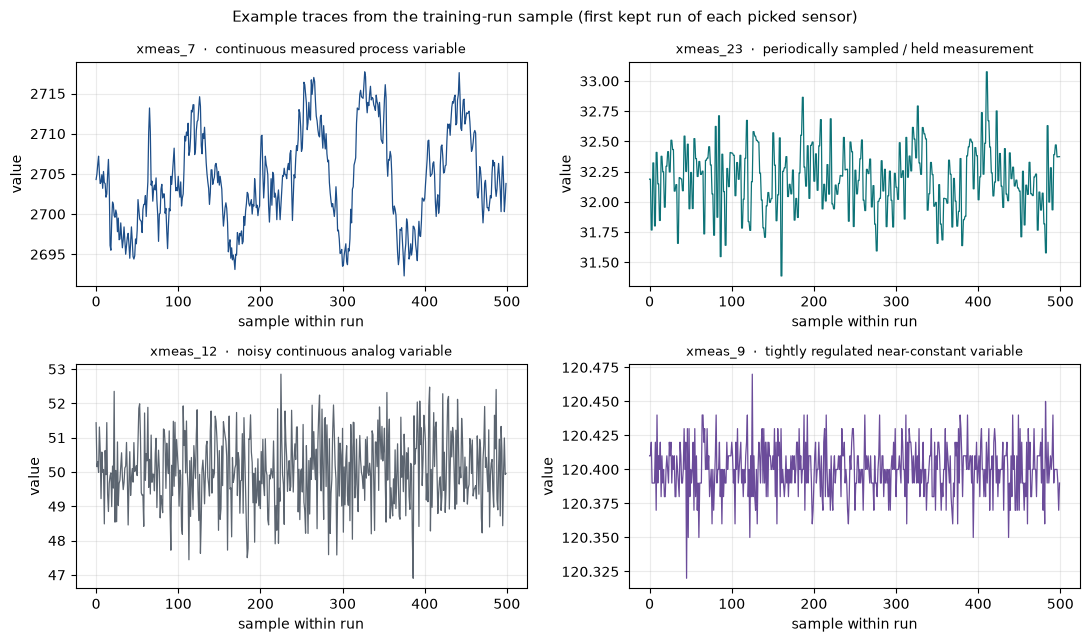

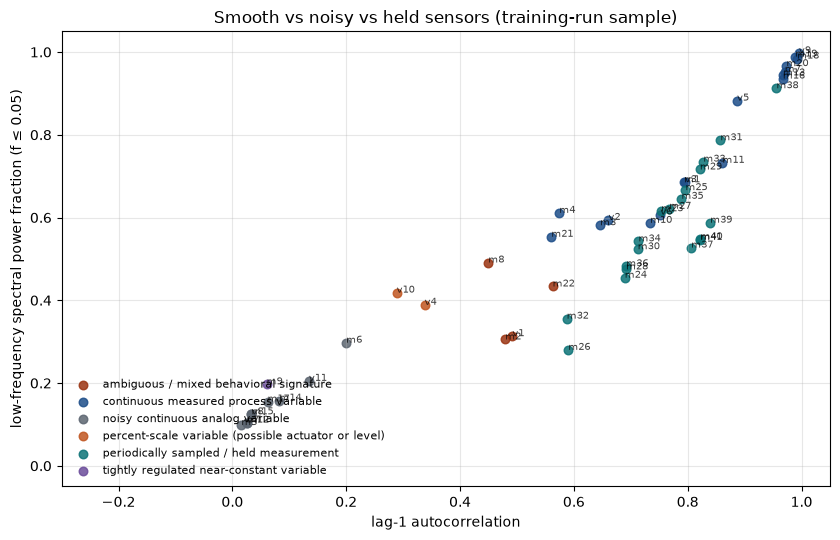

In [9]:
def _one_run(col: str) -> np.ndarray:
    runs = series_by_run(sample_df, col)
    return runs[0]


fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), sharex=False)
fig.suptitle("Example traces from the training-run sample (first kept run of each picked sensor)", fontsize=11)

picked = []
for primary in [
    "continuous measured process variable",
    "periodically sampled / held measurement",
    "noisy continuous analog variable",
    "tightly regulated near-constant variable",
]:
    subset = classified[classified["primary"] == primary]
    if subset.empty:
        continue
    picked.append((primary, subset["confidence"].idxmax()))

for ax, (primary, name) in zip(axes.ravel(), picked):
    y = _one_run(name)
    ax.plot(y, lw=0.9, color=CLASS_COLORS.get(primary, "#333"))
    ax.set_title(f"{name}  ·  {primary}", fontsize=9)
    ax.set_xlabel("sample within run")
    ax.set_ylabel("value")
    ax.grid(True, alpha=0.25)

for ax in axes.ravel()[len(picked):]:
    ax.axis("off")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 5.5))
for primary, grp in classified.groupby("primary"):
    ax.scatter(
        grp["acf_1"],
        grp["low_band_frac"],
        s=38,
        alpha=0.85,
        label=primary,
        color=CLASS_COLORS.get(primary, "#333"),
    )
    for sensor, row in grp.iterrows():
        ax.annotate(sensor.replace("xmeas_", "m").replace("xmv_", "v"), (row["acf_1"], row["low_band_frac"]),
                    fontsize=7, alpha=0.75)
ax.set_xlabel("lag-1 autocorrelation")
ax.set_ylabel("low-frequency spectral power fraction (f ≤ 0.05)")
ax.set_title("Smooth vs noisy vs held sensors (training-run sample)")
ax.set_xlim(-0.3, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower left", fontsize=8, frameon=False)
fig.tight_layout()
plt.show()



### How to read the confidence numbers

| Band | Meaning |
|---|---|
| **0.75–0.88** | Several independent clues agree (e.g. regular hold period + piecewise-constant diffs). Still not a physical identification. |
| **0.55–0.74** | The dominant pattern is clear, but another reading remains plausible. |
| **0.40–0.54** | Mixed or weak evidence. Treat the label as a hypothesis. |

A sensor with high lag-1 autocorrelation *and* a 0–100-like range is described as a continuous variable with a percent-scale hint — not as a named valve or a named temperature.
